# Tanzania Climate EDA
Exploratory Data Analysis of Tanzania's climate dataset as part of the 10 Academy Week 0 challenge.

The dataset contains daily climate records from 2015 to 2026. Key columns include:
- **T2M**: Temperature at 2 meters (°C)
- **T2M_MAX / T2M_MIN**: Daily max and min temperature
- **PRECTOTCORR**: Precipitation (mm)
- **RH2M**: Relative humidity at 2 meters (%)
- **WS2M**: Wind speed at 2 meters (m/s)
- **PS**: Surface pressure
- **QV2M**: Specific humidity
- **DOY**: Day of year

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Data
Load the Tanzania climate dataset and preview the first few rows.

In [2]:
df = pd.read_csv('../data/tanzania.csv', sep='\t')
df['Country'] = 'Tanzania'
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania


## 3. Data Overview
Check summary statistics and missing values.

In [3]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000


In [4]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
dtype: int64

## 4. Data Cleaning
Replace sentinel value -999 with NaN, remove duplicate rows, and forward-fill missing values.

In [5]:
df.replace(-999, np.nan, inplace=True)
df.drop_duplicates(inplace=True)
df.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania
4104,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania
4105,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania
4106,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,Tanzania


## 5. Feature Engineering
Create a proper date column from YEAR and DOY, then extract the Month for seasonal analysis.

In [6]:
df['date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['date'].dt.month

## 6. Visualizations
Explore seasonal patterns in temperature, rainfall, and correlations between climate variables.

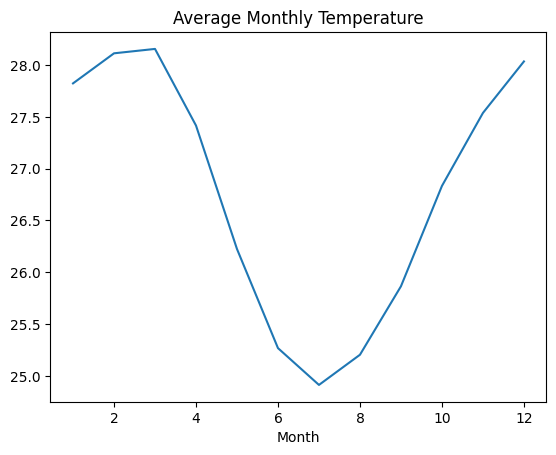

In [7]:
monthly_temp = df.groupby('Month')['T2M'].mean()
monthly_temp.plot()
plt.title('Average Monthly Temperature')
plt.show()

Tanzania has a tropical climate with temperatures generally ranging between 20–30°C. Coastal areas are warmer and more humid, while highland areas like Kilimanjaro are significantly cooler.

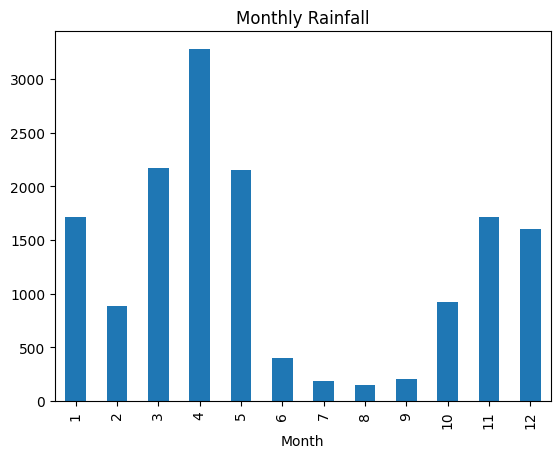

In [8]:
monthly_rain = df.groupby('Month')['PRECTOTCORR'].sum()
monthly_rain.plot(kind='bar')
plt.title('Monthly Rainfall')
plt.show()

Tanzania has two rainy seasons: the long rains (March–May) and the short rains (November–December). The dry season runs from June–October, with January–February being relatively dry as well.

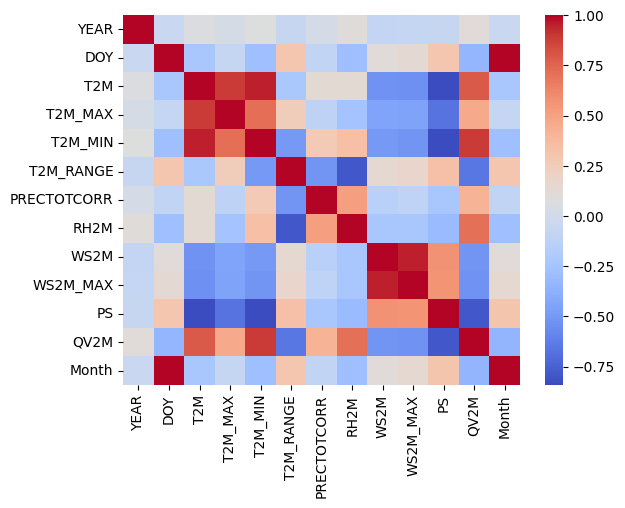

In [9]:
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

The heatmap shows strong positive correlations between T2M, T2M_MAX, and T2M_MIN. Month correlates with rainfall (PRECTOTCORR), confirming Tanzania's bimodal rainfall pattern.

## 7. Export Clean Data
Save the cleaned dataset for use in further analysis.

In [10]:
df.to_csv('../data/tanzania_clean.csv', index=False)